In [13]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [14]:
from pathlib import Path
import pandas as pd

data_path_candidates = [
    Path("copenhagen-listings.csv"),
    Path("data") / "copenhagen-listings.csv",
]

csv_path = next((p for p in data_path_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find copenhagen-listings.csv in project root or data/ directory."
    )

print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path)
print(f"Raw shape: {df.shape}")

df.head()

Loading data from: data\copenhagen-listings.csv
Raw shape: (22994, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,23500,https://www.airbnb.com/rooms/23500,20250929042231,2025-09-29,city scrape,Nice room - great area (Vesterbro),Nice and cosy room in the heart of Copenhagen ...,NaN,https://a0.muscache.com/pictures/123766/fa4694...,92053,...,5.00,5.00,4.80,NaN,f,2,1,1,0,0.08
1,29118,https://www.airbnb.com/rooms/29118,20250929042231,2025-09-29,city scrape,Best Location in Cool Istedgade,NaN,NaN,https://a0.muscache.com/pictures/b83c7003-367a...,125230,...,5.00,4.84,4.74,NaN,f,1,1,0,0,0.15
2,31094,https://www.airbnb.com/rooms/31094,20250929042231,2025-09-30,previous scrape,"Beautiful, spacious, central, renovated Penthouse","Welcome to our home, we hope you will enjoy Wo...","What else is nearby?<br />To be honest, We thi...",https://a0.muscache.com/pictures/miso/Hosting-...,129976,...,4.82,4.80,4.53,NaN,f,1,1,0,0,0.10
3,32379,https://www.airbnb.com/rooms/32379,20250929042231,2025-09-30,previous scrape,"155 m2 artist flat on Vesterbro, with 2 bathrooms",You enter a narrow entrance and feel the good ...,"Værnedamsvej area is super hip area, we call i...",https://a0.muscache.com/pictures/miso/Hosting-...,140105,...,4.92,4.89,4.71,NaN,f,2,1,1,0,0.47
4,32841,https://www.airbnb.com/rooms/32841,20250929042231,2025-09-29,city scrape,Cozy flat for Adults/Quiet for kids,Our flat is placed in a Central AND Quiet neig...,NaN,https://a0.muscache.com/pictures/28047599/8efd...,142143,...,5.00,4.50,4.50,NaN,f,1,1,0,0,0.04


In [15]:
def parse_price(value):
    """Convert Airbnb-style price strings to float (DKK)."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if not s:
        return np.nan

    # Keep only digits, comma, and dot.
    s = re.sub(r"[^\d,\.]", "", s)

    # Handle both decimal conventions robustly.
    # If comma appears after dot, treat comma as decimal separator.
    if "," in s and "." in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "")
            s = s.replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "," in s:
        s = s.replace(",", ".")

    try:
        return float(s)
    except ValueError:
        return np.nan


if "price" not in df.columns:
    raise KeyError("Expected a 'price' column in copenhagen-listings.csv")

if "price_float" in df.columns:
    df = df.drop(columns=["price_float"])

df["price_float"] = df["price"].apply(parse_price)

# Keep rows with required fields for geospatial + pricing analysis.
required_cols = ["latitude", "longitude", "price_float"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

before_null_filter = len(df)
df = df.dropna(subset=required_cols).copy()

# Coerce coordinate columns in case they were read as strings.
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"]).copy()

# Remove clearly invalid coordinates.
df = df[df["latitude"].between(-90, 90) & df["longitude"].between(-180, 180)].copy()

# IQR-based outlier filtering on price.
q1 = df["price_float"].quantile(0.25)
q3 = df["price_float"].quantile(0.75)
iqr = q3 - q1
lower = max(0, q1 - 1.5 * iqr)
upper = q3 + 1.5 * iqr

before_outlier_filter = len(df)
df = df[df["price_float"].between(lower, upper)].copy()

print(f"Rows before null filtering: {before_null_filter}")
print(f"Rows after null filtering:  {before_outlier_filter}")
print(f"Rows after outlier filter:  {len(df)}")
print(f"Price bounds used: [{lower:.2f}, {upper:.2f}]")

df[["price", "price_float", "latitude", "longitude"]].head()

Rows before null filtering: 22994
Rows after null filtering:  13442
Rows after outlier filter:  12699
Price bounds used: [0.00, 2807.50]


,price,price_float,latitude,longitude
0,$655.00,655.0,55.663620,12.545420
1,$900.00,900.0,55.670230,12.555040
4,$589.00,589.0,55.711760,12.570910
5,"$2,783.00",2783.0,55.684288,12.573019
6,"$1,829.00",1829.0,55.665070,12.583150


In [16]:
gdf_wgs84 = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

gdf_25832 = gdf_wgs84.to_crs(epsg=25832)

print("Original CRS:", gdf_wgs84.crs)
print("Projected CRS:", gdf_25832.crs)
print("Projected bounds (meters):", gdf_25832.total_bounds)

gdf_25832

Original CRS: EPSG:4326
Projected CRS: EPSG:25832
Projected bounds (meters): [ 717179.19112281 6169094.91554642  728952.79813012 6181901.42088885]


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_float,geometry
0,23500,https://www.airbnb.com/rooms/23500,20250929042231,2025-09-29,city scrape,Nice room - great area (Vesterbro),Nice and cosy room in the heart of Copenhagen ...,NaN,https://a0.muscache.com/pictures/123766/fa4694...,92053,...,4.80,NaN,f,2,1,1,0,0.08,655.0,POINT (722985.067 6174342.262)
1,29118,https://www.airbnb.com/rooms/29118,20250929042231,2025-09-29,city scrape,Best Location in Cool Istedgade,NaN,NaN,https://a0.muscache.com/pictures/b83c7003-367a...,125230,...,4.74,NaN,f,1,1,0,0,0.15,900.0,POINT (723552.109 6175108.364)
4,32841,https://www.airbnb.com/rooms/32841,20250929042231,2025-09-29,city scrape,Cozy flat for Adults/Quiet for kids,Our flat is placed in a Central AND Quiet neig...,NaN,https://a0.muscache.com/pictures/28047599/8efd...,142143,...,4.50,NaN,f,1,1,0,0,0.04,589.0,POINT (724311.516 6179778.322)
5,38499,https://www.airbnb.com/rooms/38499,20250929042231,2025-09-29,city scrape,0 min. from everything in Cph.,It doesn't get more central than this. Histori...,Area: <br />This is the eye of Cph. right betw...,https://a0.muscache.com/pictures/hosting/Hosti...,122489,...,4.88,NaN,f,1,1,0,0,0.26,2783.0,POINT (724601.53 6176729.917)
6,39055,https://www.airbnb.com/rooms/39055,20250929042231,2025-09-29,city scrape,Stylish apartment in central Copenhagen,"Big, bright, airy and attractive apartment dec...",The flat is excellently located in Islands Bry...,https://a0.muscache.com/pictures/hosting/Hosti...,167511,...,4.63,NaN,f,1,1,0,0,0.68,1829.0,POINT (725348.592 6174625.515)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22989,1519545537150512627,https://www.airbnb.com/rooms/1519545537150512627,20250929042231,2025-09-29,city scrape,Nyrenoveret 76 m² lejlighed på Islands Brygge,Enjoy a stylish experience in this newly renov...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,76615170,...,NaN,NaN,f,1,1,0,0,NaN,1088.0,POINT (725113.291 6174725.588)
22990,1519598999185426230,https://www.airbnb.com/rooms/1519598999185426230,20250929042231,2025-09-29,city scrape,Lys citylejlighed med hjemlig charme,Enjoy the Copenhagen life in this peaceful and...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,503375999,...,NaN,NaN,f,1,1,0,0,NaN,631.0,POINT (721744.076 6178259.073)
22991,1519604283209009799,https://www.airbnb.com/rooms/1519604283209009799,20250929042231,2025-09-29,city scrape,Dejlig lys og stor lejlighed i københavn,"Kick back and relax in this calm, stylish spac...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,199737223,...,NaN,NaN,t,1,1,0,0,NaN,1440.0,POINT (723267.225 6173327.705)
22992,1519717312471104080,https://www.airbnb.com/rooms/1519717312471104080,20250929042231,2025-09-29,city scrape,Bright & modern 3-BR with stunning canal views,Sluseholmen is the perfect blend of city energ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3157103,...,NaN,NaN,f,1,1,0,0,NaN,1698.0,POINT (723263.163 6172295.887)


In [17]:
from shapely.geometry import Point

# Copenhagen city centre: Rådhuspladsen / City Hall Square
cph_center_wgs84 = gpd.GeoSeries(
    [Point(12.5683, 55.6761)],  # x = longitude, y = latitude
    crs="EPSG:4326"
)

# Reproject centre point to EPSG:25832
cph_center_25832 = cph_center_wgs84.to_crs(epsg=25832).iloc[0]

# Calculate distance from each listing to city centre in kilometres
gdf_25832["distance_to_center_km"] = (
    gdf_25832.geometry.distance(cph_center_25832) / 1000
).round(2)

gdf_25832[["price_float", "latitude", "longitude", "distance_to_center_km"]].head()

,price_float,latitude,longitude,distance_to_center_km
0,655.0,55.663620,12.545420,2.00
1,900.0,55.670230,12.555040,1.06
4,589.0,55.711760,12.570910,3.97
5,2783.0,55.684288,12.573019,0.96
6,1829.0,55.665070,12.583150,1.54


In [18]:
try:
    from scipy.stats import gaussian_kde
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    gaussian_kde = None

print(f"Scipy available for KDE: {SCIPY_AVAILABLE}")

Scipy available for KDE: True


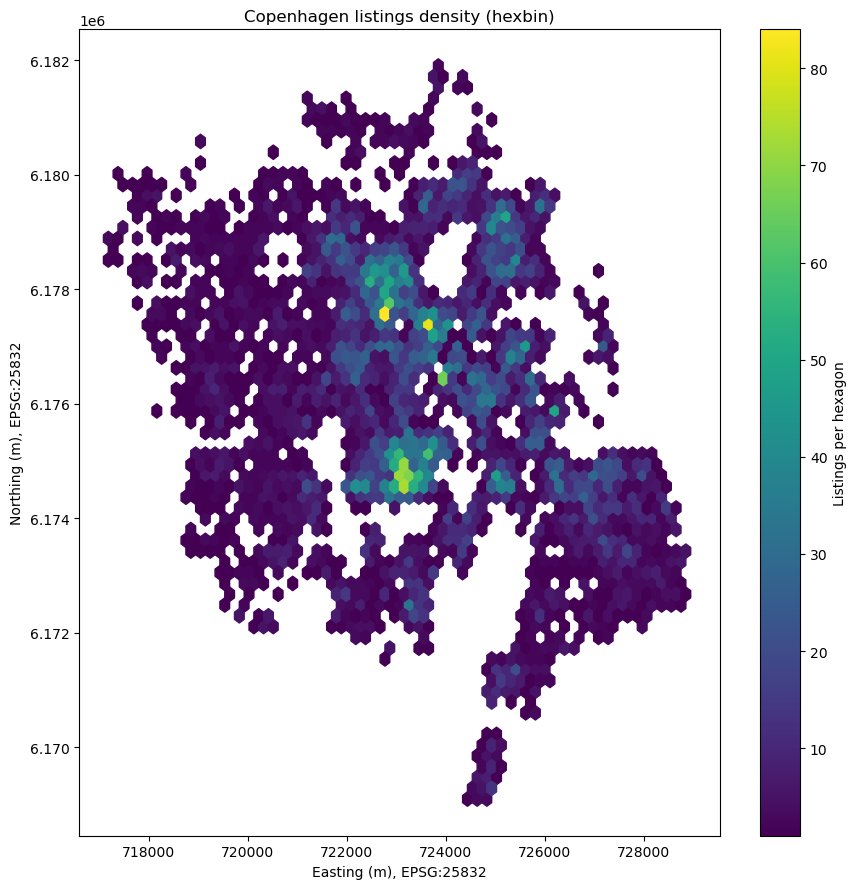

In [19]:
# --- Ex08 baseline 1: hexbin point-pattern map (metric CRS) ---
fig, ax = plt.subplots(figsize=(9, 9))

hb = ax.hexbin(
    gdf_25832.geometry.x,
    gdf_25832.geometry.y,
    gridsize=60,
    cmap="viridis",
    mincnt=1,
)

ax.set_title("Copenhagen listings density (hexbin)")
ax.set_xlabel("Easting (m), EPSG:25832")
ax.set_ylabel("Northing (m), EPSG:25832")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Listings per hexagon")

plt.tight_layout()
plt.show()

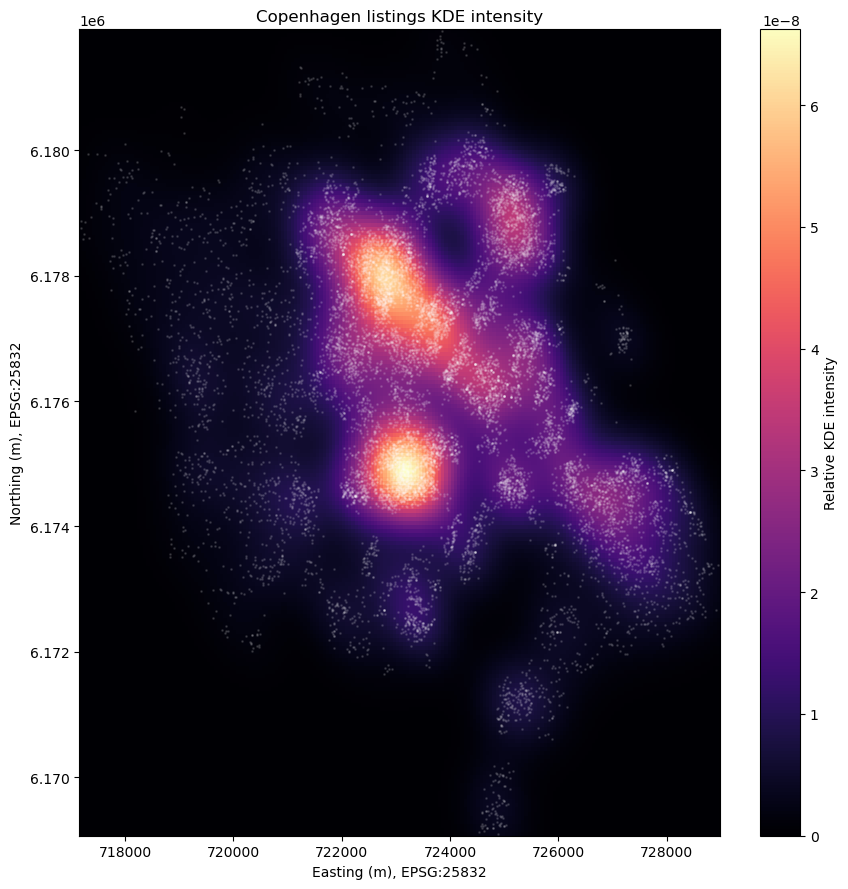

In [20]:
# --- Ex08 baseline 2: KDE surface ---
if not SCIPY_AVAILABLE:
    raise ImportError(
        "scipy is required for KDE baseline. Install with: pip install scipy"
    )

x = gdf_25832.geometry.x.to_numpy()
y = gdf_25832.geometry.y.to_numpy()
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# Evaluate density on a regular grid covering the city extent.
xmin, ymin, xmax, ymax = gdf_25832.total_bounds
grid_n = 200
xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, grid_n),
    np.linspace(ymin, ymax, grid_n),
)
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 9))
mesh = ax.pcolormesh(xx, yy, zz, shading="auto", cmap="magma")
ax.scatter(x, y, s=1, alpha=0.12, color="white")
ax.set_title("Copenhagen listings KDE intensity")
ax.set_xlabel("Easting (m), EPSG:25832")
ax.set_ylabel("Northing (m), EPSG:25832")
cb = fig.colorbar(mesh, ax=ax)
cb.set_label("Relative KDE intensity")

plt.tight_layout()
plt.show()

In [21]:
# --- Ex08 baseline 3: point-in-neighbourhood summary ---
neighbourhood_col_candidates = [
    "neighbourhood_cleansed",
    "neighbourhood",
    "neighbourhood_group_cleansed",
]

neighbourhood_col = next((c for c in neighbourhood_col_candidates if c in gdf_25832.columns), None)
if neighbourhood_col is None:
    raise KeyError(
        "No neighbourhood column found. Expected one of: "
        f"{neighbourhood_col_candidates}"
    )

point_in_neighbourhood = (
    gdf_25832.dropna(subset=[neighbourhood_col])
    .groupby(neighbourhood_col)
    .size()
    .sort_values(ascending=False)
    .rename("listing_count")
    .to_frame()
)

print(f"Using neighbourhood column: {neighbourhood_col}")
print(f"Neighbourhoods with listings: {len(point_in_neighbourhood)}")
point_in_neighbourhood.head(15)

Using neighbourhood column: neighbourhood_cleansed
Neighbourhoods with listings: 11


,listing_count
neighbourhood_cleansed,
Vesterbro-Kongens Enghave,2214
Nrrebro,2190
Indre By,1822
sterbro,1380
Frederiksberg,1329
Amager Vest,1172
Amager st,985
Bispebjerg,591
Valby,465


In [22]:
# --- Ex08-style neighbourhood counts + density join ---

# Pick listing neighbourhood column used earlier.
neighbourhood_col_candidates = [
    "neighbourhood_cleansed",
    "neighbourhood",
    "neighbourhood_group_cleansed",
]
neighbourhood_col = next((c for c in neighbourhood_col_candidates if c in gdf_25832.columns), None)
if neighbourhood_col is None:
    raise KeyError(f"No neighbourhood column found in listings: {neighbourhood_col_candidates}")

if "neighbourhood" not in neis_25832.columns:
    raise KeyError("Expected 'neighbourhood' column in neighbourhood polygons")

# Normalize names to improve match rate.
def norm_name(s):
    if pd.isna(s):
        return ""
    return str(s).strip().lower()

listing_counts = (
    gdf_25832.assign(nei_key=gdf_25832[neighbourhood_col].map(norm_name))
    .groupby("nei_key")
    .size()
    .rename("abb_count")
    .to_frame()
)

neis_25832 = neis_25832.copy()
neis_25832["nei_key"] = neis_25832["neighbourhood"].map(norm_name)

neis_joined = neis_25832.merge(listing_counts, on="nei_key", how="left")
neis_joined["abb_count"] = neis_joined["abb_count"].fillna(0)

# Density in listings per km^2.
neis_joined["area_km2"] = neis_joined.geometry.area / 1_000_000
neis_joined["abb_density_km2"] = neis_joined["abb_count"] / neis_joined["area_km2"]

print(f"Using listing neighbourhood column: {neighbourhood_col}")
print(f"Matched neighbourhood polygons: {(neis_joined['abb_count'] > 0).sum()} / {len(neis_joined)}")
neis_joined[["neighbourhood", "abb_count", "area_km2", "abb_density_km2"]]

NameError: name 'neis_25832' is not defined

NameError: name 'neis_joined' is not defined

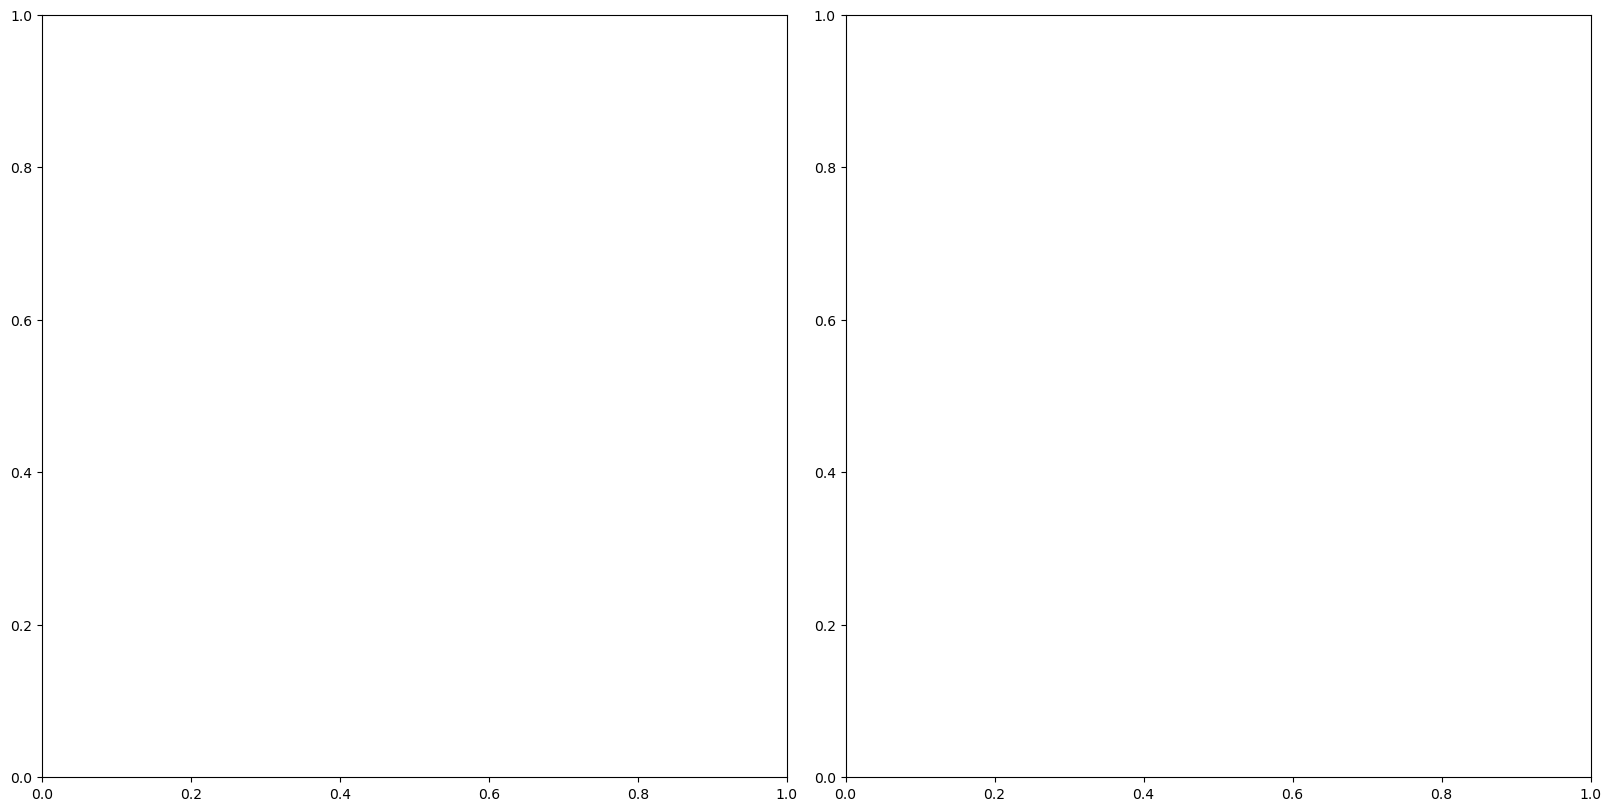

In [23]:
# --- Ex08-style maps: raw count and density by neighbourhood ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

neis_joined.plot(
    column="abb_count",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    legend_kwds={"title": "Listing count", "loc": "lower left"},
    ax=axes[0],
)
axes[0].set_title("Airbnb count by neighbourhood")
axes[0].set_axis_off()

neis_joined.plot(
    column="abb_density_km2",
    cmap="magma",
    scheme="quantiles",
    k=5,
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    legend_kwds={"title": "Listings per km²", "loc": "lower left"},
    ax=axes[1],
)
axes[1].set_title("Airbnb density by neighbourhood (per km²)")
axes[1].set_axis_off()

plt.show()

In [ ]:
# --- H3 spatial unit: assign each listing to an H3 hex ---
# Use a city-scale resolution suitable for neighbourhood-level analysis.
H3_RESOLUTION = 8

try:
    import h3
except ImportError as exc:
    raise ImportError(
        "h3 is required for hex aggregation. Install with: pip install h3"
    ) from exc

# H3 indexing uses latitude/longitude in WGS84.
listings_h3 = gdf_wgs84.copy()
listings_h3["h3_id"] = listings_h3.apply(
    lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, H3_RESOLUTION),
    axis=1,
)

print(f"H3 resolution: {H3_RESOLUTION}")
print(f"Listings assigned: {len(listings_h3)}")
print(f"Unique hex cells: {listings_h3['h3_id'].nunique()}")

listings_h3[["h3_id", "price_float", "latitude", "longitude"]].head()

ImportError: h3 is required for hex aggregation. Install with: pip install h3

In [ ]:
# --- Aggregate listings to H3 hex cells ---
agg_spec = {
    "price_float": ["median", "mean", "min", "max"],
}

# Add optional numeric fields when available.
optional_numeric = ["accommodates", "bedrooms", "beds", "bathrooms"]
for col in optional_numeric:
    if col in listings_h3.columns:
        listings_h3[col] = pd.to_numeric(listings_h3[col], errors="coerce")
        agg_spec[col] = ["mean", "median"]

h3_agg = listings_h3.groupby("h3_id").agg(agg_spec)

# Flatten MultiIndex column names.
h3_agg.columns = ["_".join([c for c in col if c]).strip("_") for col in h3_agg.columns]
h3_agg = h3_agg.rename(
    columns={
        "price_float_median": "median_price",
        "price_float_mean": "mean_price",
        "price_float_min": "min_price",
        "price_float_max": "max_price",
    }
)

# Add listing count (core baseline metric).
h3_agg["listing_count"] = listings_h3.groupby("h3_id").size()

# Build hexagon polygons from H3 cell boundaries.
def h3_to_polygon(cell_id: str):
    # h3 returns (lat, lon), shapely expects (x=lon, y=lat)
    boundary = h3.cell_to_boundary(cell_id)
    return Polygon([(lng, lat) for lat, lng in boundary])

from shapely.geometry import Polygon

h3_agg = h3_agg.reset_index()
h3_agg["geometry"] = h3_agg["h3_id"].apply(h3_to_polygon)

h3_grid_wgs84 = gpd.GeoDataFrame(h3_agg, geometry="geometry", crs="EPSG:4326")
h3_grid_25832 = h3_grid_wgs84.to_crs(epsg=25832)

# Order by density for quick inspection.
h3_grid_25832 = h3_grid_25832.sort_values("listing_count", ascending=False).reset_index(drop=True)

print(f"Hex cells in grid: {len(h3_grid_25832)}")
print("Columns available:")
print([c for c in h3_grid_25832.columns if c != "geometry"])

h3_grid_25832.head()

Hex cells in grid: 162
Columns available:
['h3_id', 'median_price', 'mean_price', 'min_price', 'max_price', 'accommodates_mean', 'accommodates_median', 'bedrooms_mean', 'bedrooms_median', 'beds_mean', 'beds_median', 'bathrooms_mean', 'bathrooms_median', 'listing_count']


,h3_id,median_price,mean_price,min_price,max_price,accommodates_mean,accommodates_median,bedrooms_mean,bedrooms_median,beds_mean,beds_median,bathrooms_mean,bathrooms_median,listing_count,geometry
0,881f058339fffff,1223.0,1306.001684,314.0,2750.0,3.102694,2.5,1.476431,1.0,1.695286,1.0,1.031145,1.0,594,"POLYGON ((722909.855 6175496.123, 722790.582 6..."
1,881f058351fffff,1035.0,1113.990020,270.0,2728.0,2.894212,2.0,1.334000,1.0,1.524950,1.0,1.015968,1.0,501,"POLYGON ((722771.409 6178355.556, 722652.166 6..."
2,881f05833dfffff,1201.5,1276.259174,323.0,2805.0,3.316514,3.0,1.571101,1.0,1.777523,2.0,1.095183,1.0,436,"POLYGON ((722303.899 6174868.110, 722184.602 6..."
3,881f058331fffff,1170.0,1243.814536,360.0,2800.0,2.964912,2.0,1.380952,1.0,1.571429,1.0,1.031407,1.0,399,"POLYGON ((723158.002 6174752.043, 723038.726 6..."
4,881f058357fffff,1201.5,1265.876923,345.0,2726.0,2.974359,2.0,1.415385,1.0,1.530769,1.0,1.028205,1.0,390,"POLYGON ((723019.501 6177611.839, 722900.256 6..."


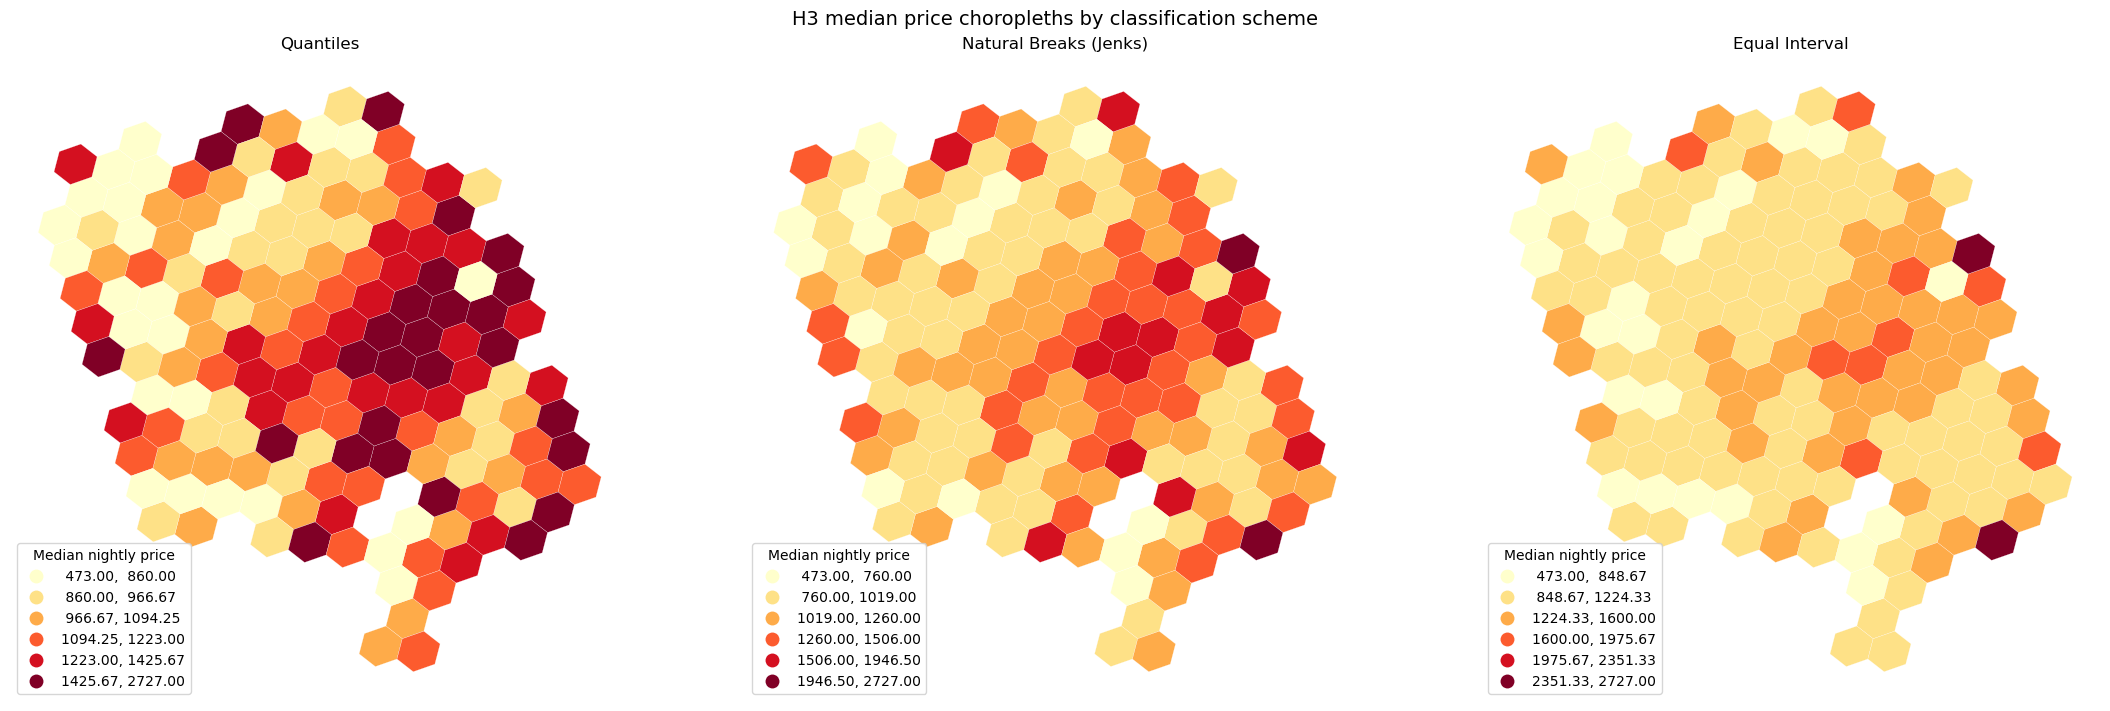

In [ ]:
# --- Exploratory choropleths: compare classification schemes ---
try:
    import mapclassify  # noqa: F401 (used internally by geopandas plotting)
except ImportError as exc:
    raise ImportError(
        "mapclassify is required for scheme-based choropleths. Install with: pip install mapclassify"
    ) from exc

if "median_price" not in h3_grid_25832.columns:
    raise KeyError("Expected 'median_price' in h3_grid_25832")

plot_gdf = h3_grid_25832.dropna(subset=["median_price"]).copy()
if plot_gdf.empty:
    raise ValueError("No hex cells with median_price available for choropleth mapping")

schemes = [
    ("quantiles", "Quantiles"),
    ("natural_breaks", "Natural Breaks (Jenks)"),
    ("equal_interval", "Equal Interval"),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7), constrained_layout=True)

for ax, (scheme_key, title) in zip(axes, schemes):
    plot_gdf.plot(
        column="median_price",
        scheme=scheme_key,
        k=6,
        cmap="YlOrRd",
        linewidth=0.15,
        edgecolor="white",
        legend=True,
        legend_kwds={"title": "Median nightly price", "loc": "lower left"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()

fig.suptitle("H3 median price choropleths by classification scheme", fontsize=14)
plt.show()

In [ ]:
# Optional: quick class-bin inspection for each scheme
values = plot_gdf["median_price"].to_numpy()

classifiers = {
    "quantiles": mapclassify.Quantiles(values, k=6),
    "natural_breaks": mapclassify.NaturalBreaks(values, k=6),
    "equal_interval": mapclassify.EqualInterval(values, k=6),
}

for name, clf in classifiers.items():
    print(f"\n{name} bins:")
    print(np.round(clf.bins, 2))


quantiles bins:
[ 860.    966.67 1094.25 1223.   1425.67 2727.  ]

natural_breaks bins:
[ 760.  1019.  1234.  1506.  1946.5 2727. ]

equal_interval bins:
[ 848.67 1224.33 1600.   1975.67 2351.33 2727.  ]


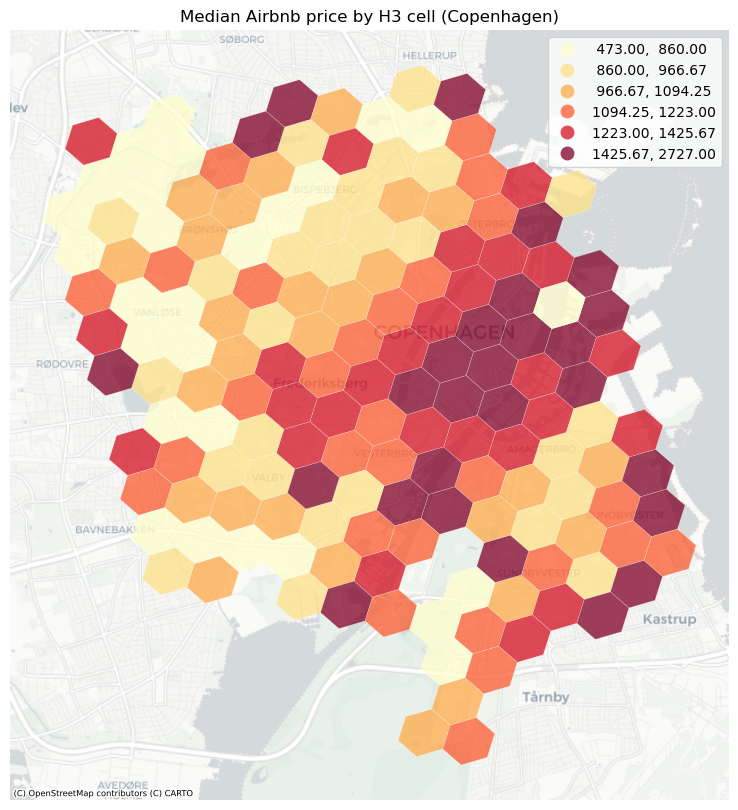

In [ ]:
# Example: your hex grid (currently EPSG:25832) -> EPSG:3857 for tile basemaps
hex_3857 = h3_grid_25832.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

hex_3857.plot(
    column="median_price",
    cmap="YlOrRd",
    scheme="quantiles",
    k=6,
    alpha=0.75,          # slightly transparent so basemap is visible
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    ax=ax,
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,  # clean grayscale city map
    attribution_size=6
)

ax.set_axis_off()
ax.set_title("Median Airbnb price by H3 cell (Copenhagen)")
plt.show()

In [ ]:
if "hex_gdf_clean" not in globals():
    raise NameError(
        "hex_gdf_clean not found. Run the handoff dataset cell first."
    )

output_dir = Path("preprocessed data")
output_dir.mkdir(parents=True, exist_ok=True)

csv_out = output_dir / "hex_listing_aggregates_epsg25832.csv"

# CSV is tabular only: drop geometry and keep the shared metric fields.
hex_table = hex_gdf_clean.drop(columns=["geometry"], errors="ignore").copy()
hex_table.to_csv(csv_out, index=False)

print(f"CSV exported: {csv_out}")
print(f"Rows: {len(hex_table)} | Columns: {len(hex_table.columns)}")
hex_table.head()

CSV exported: preprocessed data/hex_listing_aggregates_epsg25832.csv
Rows: 162 | Columns: 14


,h3_id,listing_count,median_price,mean_price,min_price,max_price,accommodates_mean,accommodates_median,bedrooms_mean,bedrooms_median,beds_mean,beds_median,bathrooms_mean,bathrooms_median
0,881f058339fffff,594,1223.0,1306.001684,314.0,2750.0,3.102694,2.5,1.476431,1.0,1.695286,1.0,1.031145,1.0
1,881f058351fffff,501,1035.0,1113.990020,270.0,2728.0,2.894212,2.0,1.334000,1.0,1.524950,1.0,1.015968,1.0
2,881f05833dfffff,436,1201.5,1276.259174,323.0,2805.0,3.316514,3.0,1.571101,1.0,1.777523,2.0,1.095183,1.0
3,881f058331fffff,399,1170.0,1243.814536,360.0,2800.0,2.964912,2.0,1.380952,1.0,1.571429,1.0,1.031407,1.0
4,881f058357fffff,390,1201.5,1265.876923,345.0,2726.0,2.974359,2.0,1.415385,1.0,1.530769,1.0,1.028205,1.0


In [ ]:
# --- Ex08-style neighbourhood join: load polygon layer ---
url_neis = "https://data.insideairbnb.com/denmark/hovedstaden/copenhagen/2025-09-29/visualisations/neighbourhoods.geojson"

neis = gpd.read_file(url_neis)

# Work in metric CRS for area-based density calculations.
neis_25832 = neis.to_crs(epsg=25832)

print(f"Neighbourhood polygons loaded: {len(neis_25832)}")
print(f"CRS: {neis_25832.crs}")
neis_25832.head()

Neighbourhood polygons loaded: 11
CRS: EPSG:25832


,neighbourhood,neighbourhood_group,geometry
0,Frederiksberg,NaN,"MULTIPOLYGON (((721681.387 6177839.608, 721718..."
1,Brnshj-Husum,NaN,"MULTIPOLYGON (((717975.903 6178117.771, 717850..."
2,sterbro,NaN,"MULTIPOLYGON (((726044.464 6178944.812, 725990..."
3,Indre By,NaN,"MULTIPOLYGON (((726941.056 6178339.123, 727181..."
4,Nrrebro,NaN,"MULTIPOLYGON (((722271.619 6177975.076, 722290..."


Using listing neighbourhood column: neighbourhood_cleansed
Matched neighbourhood polygons: 11 / 11


,neighbourhood,abb_count,area_km2,abb_density_km2
0,Frederiksberg,1329,8.710690,152.571154
1,Brnshj-Husum,227,8.736514,25.982902
2,sterbro,1380,9.835982,140.301191
3,Indre By,1822,10.387319,175.406187
4,Nrrebro,2190,4.104595,533.548423


In [ ]:
# --- Handoff dataset: clean hex-level GeoDataFrame for downstream users ---

# Keep the core columns that downstream analyses rely on.
base_cols = [
    "h3_id",
    "listing_count",
    "median_price",
    "mean_price",
    "min_price",
    "max_price",
    "geometry",
]

# Add optional aggregated fields if available.
optional_cols = [
    "accommodates_mean",
    "accommodates_median",
    "bedrooms_mean",
    "bedrooms_median",
    "beds_mean",
    "beds_median",
    "bathrooms_mean",
    "bathrooms_median",
]

selected_cols = [c for c in base_cols + optional_cols if c in h3_grid_25832.columns]
hex_gdf_clean = h3_grid_25832[selected_cols].copy()

# Enforce stable dtypes and remove clearly invalid rows.
hex_gdf_clean["h3_id"] = hex_gdf_clean["h3_id"].astype(str)
hex_gdf_clean = hex_gdf_clean.dropna(subset=["geometry", "listing_count", "median_price"]).copy()
hex_gdf_clean = hex_gdf_clean[hex_gdf_clean["listing_count"] > 0].copy()
hex_gdf_clean = hex_gdf_clean.sort_values(["listing_count", "median_price"], ascending=[False, False]).reset_index(drop=True)

# Export both portable geospatial and fast tabular-geospatial formats.
output_dir = Path("preprocessed data")
output_dir.mkdir(parents=True, exist_ok=True)

hex_geojson_path = output_dir / "hex_listing_aggregates_epsg25832.geojson"
hex_parquet_path = output_dir / "hex_listing_aggregates_epsg25832.parquet"

hex_gdf_clean.to_file(hex_geojson_path, driver="GeoJSON")
hex_gdf_clean.to_parquet(hex_parquet_path, index=False)

print("Hex-level handoff dataset ready")
print(f"Rows: {len(hex_gdf_clean)}")
print(f"CRS: {hex_gdf_clean.crs}")
print(f"GeoJSON: {hex_geojson_path}")
print(f"Parquet: {hex_parquet_path}")

hex_gdf_clean.head()

Hex-level handoff dataset ready
Rows: 162
CRS: EPSG:25832
GeoJSON: preprocessed data/hex_listing_aggregates_epsg25832.geojson
Parquet: preprocessed data/hex_listing_aggregates_epsg25832.parquet


,h3_id,listing_count,median_price,mean_price,min_price,max_price,geometry,accommodates_mean,accommodates_median,bedrooms_mean,bedrooms_median,beds_mean,beds_median,bathrooms_mean,bathrooms_median
0,881f058339fffff,594,1223.0,1306.001684,314.0,2750.0,"POLYGON ((722909.855 6175496.123, 722790.582 6...",3.102694,2.5,1.476431,1.0,1.695286,1.0,1.031145,1.0
1,881f058351fffff,501,1035.0,1113.990020,270.0,2728.0,"POLYGON ((722771.409 6178355.556, 722652.166 6...",2.894212,2.0,1.334000,1.0,1.524950,1.0,1.015968,1.0
2,881f05833dfffff,436,1201.5,1276.259174,323.0,2805.0,"POLYGON ((722303.899 6174868.110, 722184.602 6...",3.316514,3.0,1.571101,1.0,1.777523,2.0,1.095183,1.0
3,881f058331fffff,399,1170.0,1243.814536,360.0,2800.0,"POLYGON ((723158.002 6174752.043, 723038.726 6...",2.964912,2.0,1.380952,1.0,1.571429,1.0,1.031407,1.0
4,881f058357fffff,390,1201.5,1265.876923,345.0,2726.0,"POLYGON ((723019.501 6177611.839, 722900.256 6...",2.974359,2.0,1.415385,1.0,1.530769,1.0,1.028205,1.0
